# Step 2: The velocity solver and its test

How fast does the ice move, given its thickness? In a fast-sliding ice sheet and in a floating ice shelf, the ice moves almost like a solid plug: the velocity is nearly the same at every depth. This is the shallow-shelf approximation (SSA). In this notebook I explain the solver I wrote in `flowline.py` (`solve_ssa`) and test it against an exact solution for a floating ice shelf.

I load the libraries and the model functions, and set the parameters of the tests. The shelf tests use a deep bed (2000 m below sea level), so the ice floats everywhere and there is no friction. Units: metres, years, Pa.

In [1]:
%matplotlib inline

import os
import time

import numpy as np
import matplotlib.pyplot as plt

from flowline import (RHO_I, RHO_W, G, N_GLEN, a_per_year, make_grid, surface_elevation, effective_viscosity,
                      solve_ssa)

A_TEST_SI = 1e-25                 # rate factor for the tests (Pa^-3 s^-1), one of the MISMIP values
A_TEST = a_per_year(A_TEST_SI)    # the same in Pa^-3 yr^-1
SHELF_LENGTH = 200e3              # length of the test shelf (m)
H_UNIFORM = 500.0                 # thickness of the uniform shelf (m)
H_UPSTREAM, H_FRONT = 1000.0, 400.0   # thickness at the two ends of the thinning shelf (m)
BED_DEEP = -2000.0                # bed elevation under the test shelves (m): deep enough to float everywhere
DX_LIST = [20e3, 10e3, 5e3, 2.5e3, 1.25e3, 0.625e3]   # grid spacings to test (m)
STRAIN_RATE_REG = 1e-6            # floor on the strain rate in the viscosity (1/yr)
TOL = 1e-13                       # Picard stops when the largest change in u is below TOL x the largest speed
FIG_DIR = "../figures"
DATA_DIR = "../data"

## The equation in plain words

At every point the forces on a column of ice must balance:

d/dx [ 4 eta H du/dx ]  -  beta u  =  rho_i g H ds/dx

- The first term is the stretching (longitudinal) stress: neighbouring ice pulls on the column when the ice stretches. eta is the viscosity, H the thickness, du/dx the stretching rate.
- The second term is basal friction: beta u = C |u|^(m-1) u, only under grounded ice.
- The right-hand side is the driving stress: the weight of the ice pushes it down the surface slope ds/dx.

Boundary conditions: u = 0 at the ice divide (ice flows away on both sides, so not across it), and at the calving front the stretching stress must balance the push of the ice cliff minus the push of the seawater on its submerged part.

Glen's flow law makes the ice softer when it deforms faster: eta = 0.5 A^(-1/n) |du/dx|^((1-n)/n). That makes the equation nonlinear.

## The staggered grid

Thickness lives at cell centres and velocity at cell edges. Here is a small example, 10 km long with 2 km cells. Why: the ice flux u H across an edge is exactly what moves ice from one cell to the next (step 3), the surface slope between two centres is naturally an edge value (where the driving stress acts), and du/dx between two edges is naturally a centre value (where eta and H are). Putting everything at the same points would need averages everywhere and lets the solution develop a zigzag that the equations cannot see.

In [2]:
x_edges, x_centres = make_grid(10e3, 2e3)
print("edges (velocity):   ", x_edges / 1e3, "km")
print("centres (thickness):", x_centres / 1e3, "km")

edges (velocity):    [ 0.  2.  4.  6.  8. 10.] km
centres (thickness): [1. 3. 5. 7. 9.] km


## Picard iteration and the regularization

The viscosity depends on du/dx and the friction coefficient on u, so I cannot solve the equation in one go. Picard iteration: compute eta and beta from the current guess of u, which turns the equation into a linear one with three unknowns per row (u at an edge and its two neighbours). That tridiagonal system is solved directly with `scipy.linalg.solve_banded`. Then repeat with the new u until it stops changing.

Regularization: where the ice barely stretches, as at the very first iteration when u = 0, eta = 0.5 A^(-1/3) |du/dx|^(-2/3) would be infinite. I replace |du/dx| by sqrt((du/dx)^2 + 1e-6^2), a floor of 1e-6 per year, far below the real stretching rates in this problem (about 4e-3 per year here). The friction coefficient gets a similar floor on the speed (1e-3 m/yr), because C |u|^(m-1) is infinite at u = 0.

The plot shows the largest relative change in u at each iteration for the uniform shelf, starting from u = 0.

converged in 77 iterations; change in the last 5: [5.50969552e-13 3.91014986e-13 2.45039642e-13 1.65062359e-13
 9.46285836e-14]
each iteration reduces the change by about a factor 0.667


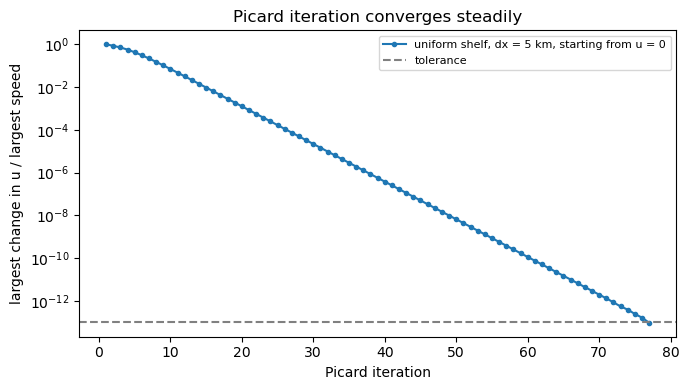

In [3]:
x_edges, x_centres = make_grid(SHELF_LENGTH, 5e3)
h = np.full(len(x_centres), H_UNIFORM)
b = np.full(len(x_centres), BED_DEEP)
floating = np.zeros(len(x_edges))                       # grounded fraction 0 at every edge
u, n_iter, changes = solve_ssa(h, b, 5e3, A_TEST, floating, strain_rate_reg=STRAIN_RATE_REG, tol=TOL)
print(f"converged in {n_iter} iterations; change in the last 5: {np.array(changes[-5:])}")
print(f"each iteration reduces the change by about a factor {np.exp(np.mean(np.diff(np.log(changes[10:60])))):.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(np.arange(1, n_iter + 1), changes, "o-", ms=3, label="uniform shelf, dx = 5 km, starting from u = 0")
ax.axhline(TOL, color="0.5", ls="--", label="tolerance")
ax.set_xlabel("Picard iteration")
ax.set_ylabel("largest change in u / largest speed")
ax.set_title("Picard iteration converges steadily")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_picard_convergence.png"), dpi=150)
plt.show()

## Test 1: a floating shelf of uniform thickness

For a freely floating shelf of uniform thickness H, the stretching stress must balance the cliff at the front everywhere (there is no friction and no surface slope), which gives a constant stretching rate:

du/dx = A ( rho_i g (1 - rho_i/rho_w) H / 4 )^n

so u = (du/dx) x, starting from u = 0 at x = 0. I compare the solver with this at six grid spacings.

In [4]:
rate_exact = A_TEST * (RHO_I * G * (1.0 - RHO_I / RHO_W) * H_UNIFORM / 4.0) ** N_GLEN
print(f"exact stretching rate {rate_exact:.6e} per year; speed at the front {rate_exact * SHELF_LENGTH:.3f} m/yr")
errors_uniform = []
for dx in DX_LIST:
    x_edges, x_centres = make_grid(SHELF_LENGTH, dx)
    h = np.full(len(x_centres), H_UNIFORM)
    b = np.full(len(x_centres), BED_DEEP)
    u, n_iter, changes = solve_ssa(h, b, dx, A_TEST, np.zeros(len(x_edges)), strain_rate_reg=STRAIN_RATE_REG, tol=TOL)
    err = np.max(np.abs(u - rate_exact * x_edges)) / (rate_exact * SHELF_LENGTH)
    errors_uniform.append(err)
    print(f"dx = {dx / 1e3:6.3f} km: {len(x_centres):4d} cells, {n_iter} iterations, largest error / front speed = {err:.3e}")

exact stretching rate 4.228930e-03 per year; speed at the front 845.786 m/yr
dx = 20.000 km:   10 cells, 78 iterations, largest error / front speed = 5.592e-08
dx = 10.000 km:   20 cells, 78 iterations, largest error / front speed = 5.592e-08
dx =  5.000 km:   40 cells, 77 iterations, largest error / front speed = 5.592e-08
dx =  2.500 km:   80 cells, 78 iterations, largest error / front speed = 5.592e-08
dx =  1.250 km:  160 cells, 76 iterations, largest error / front speed = 5.592e-08
dx =  0.625 km:  320 cells, 98 iterations, largest error / front speed = 5.592e-08


The error is the same, about 5.6e-8, at every grid spacing. The exact solution is a straight line, and my centred differences reproduce a straight line exactly, so there is no discretization error to see. What is left is the regularization: the floor on the strain rate makes the ice very slightly stiffer, by a relative amount of about (floor / strain rate)^2 = (1e-6 / 4.2e-3)^2 = 5.6e-8. I check this by changing the floor.

In [5]:
dx = 5e3
x_edges, x_centres = make_grid(SHELF_LENGTH, dx)
h = np.full(len(x_centres), H_UNIFORM)
b = np.full(len(x_centres), BED_DEEP)
for reg in [1e-4, 1e-5, 1e-6, 1e-7]:
    u, n_iter, changes = solve_ssa(h, b, dx, A_TEST, np.zeros(len(x_edges)), strain_rate_reg=reg, tol=TOL)
    err = np.max(np.abs(u - rate_exact * x_edges)) / (rate_exact * SHELF_LENGTH)
    print(f"floor {reg:.0e} per year: error {err:.3e} | (floor / strain rate)^2 = {(reg / rate_exact) ** 2:.3e}")

floor 1e-04 per year: error 5.585e-04 | (floor / strain rate)^2 = 5.592e-04
floor 1e-05 per year: error 5.592e-06 | (floor / strain rate)^2 = 5.592e-06
floor 1e-06 per year: error 5.592e-08 | (floor / strain rate)^2 = 5.592e-08
floor 1e-07 per year: error 5.590e-10 | (floor / strain rate)^2 = 5.592e-10


## Test 2: a shelf that thins toward the front

To measure how the error shrinks with grid spacing, I need an exact solution that is not a straight line. The same idea gives one. On a freely floating shelf the driving stress is rho_i g H d/dx[(1 - rho_i/rho_w) H], which is the derivative of 0.5 rho_i g (1 - rho_i/rho_w) H^2. So the stretching stress at every point equals the push of a cliff of the local thickness, and

du/dx = A ( rho_i g (1 - rho_i/rho_w) H(x) / 4 )^n   at every x.

For a thickness falling linearly from 1000 m to 400 m over 200 km, H(x) = H1 + H' x, integrating with n = 3 gives u(x) = k (H(x)^4 - H1^4) / (4 H') with k = A (rho_i g (1 - rho_i/rho_w) / 4)^3.

In [6]:
k_shelf = A_TEST * (RHO_I * G * (1.0 - RHO_I / RHO_W) / 4.0) ** N_GLEN
slope = (H_FRONT - H_UPSTREAM) / SHELF_LENGTH

def u_exact_thinning(x):
    return k_shelf * ((H_UPSTREAM + slope * x) ** 4 - H_UPSTREAM ** 4) / (4.0 * slope)

errors_thinning = []
run_times = []
solutions = {}
for dx in DX_LIST:
    x_edges, x_centres = make_grid(SHELF_LENGTH, dx)
    h = H_UPSTREAM + slope * x_centres
    b = np.full(len(x_centres), BED_DEEP)
    start = time.time()
    u, n_iter, changes = solve_ssa(h, b, dx, A_TEST, np.zeros(len(x_edges)), strain_rate_reg=STRAIN_RATE_REG, tol=TOL)
    run_times.append(time.time() - start)
    u_ex = u_exact_thinning(x_edges)
    err = np.max(np.abs(u - u_ex)) / np.max(u_ex)
    errors_thinning.append(err)
    solutions[dx] = (x_edges, u)
    print(f"dx = {dx / 1e3:6.3f} km: {n_iter} iterations, {run_times[-1]:.3f} s, largest error / front speed = {err:.3e}")
print(f"exact speed at the front: {u_exact_thinning(SHELF_LENGTH):.2f} m/yr")

dx = 20.000 km: 78 iterations, 0.003 s, largest error / front speed = 1.552e-03
dx = 10.000 km: 78 iterations, 0.002 s, largest error / front speed = 3.879e-04
dx =  5.000 km: 79 iterations, 0.002 s, largest error / front speed = 9.697e-05
dx =  2.500 km: 77 iterations, 0.002 s, largest error / front speed = 2.424e-05
dx =  1.250 km: 82 iterations, 0.003 s, largest error / front speed = 6.052e-06
dx =  0.625 km: 77 iterations, 0.004 s, largest error / front speed = 1.506e-06
exact speed at the front: 2747.11 m/yr


The numerical and exact velocities along the thinning shelf, for the coarsest grid and a fine one.

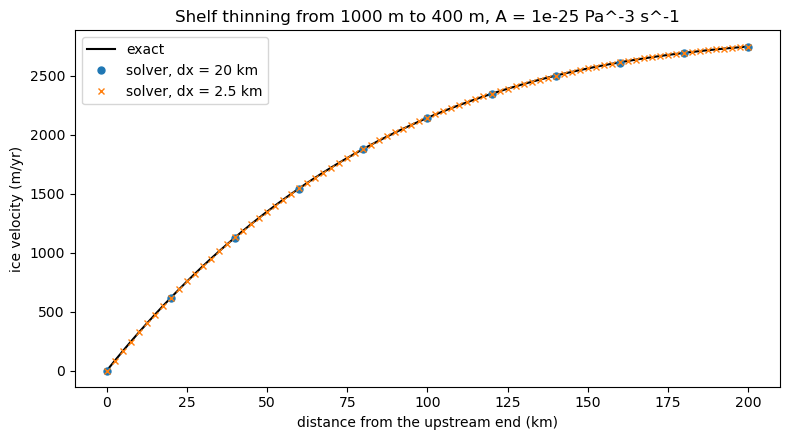

In [7]:
x_fine = np.linspace(0.0, SHELF_LENGTH, 400)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_fine / 1e3, u_exact_thinning(x_fine), color="k", label="exact")
for dx, style in [(DX_LIST[0], "o"), (DX_LIST[3], "x")]:
    x_edges, u = solutions[dx]
    ax.plot(x_edges / 1e3, u, style, ms=5, label=f"solver, dx = {dx / 1e3:g} km")
ax.set_xlabel("distance from the upstream end (km)")
ax.set_ylabel("ice velocity (m/yr)")
ax.set_title(f"Shelf thinning from {H_UPSTREAM:.0f} m to {H_FRONT:.0f} m, A = {A_TEST_SI:.0e} Pa^-3 s^-1")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_shelf_velocity.png"), dpi=150)
plt.show()

The error against grid spacing on log-log axes. The slope of the line through the points is the convergence rate: 2 means that halving dx divides the error by 4.

convergence rate (fit through all points): 2.001
rate between neighbouring grid spacings: [2.    2.    2.    2.002 2.007]


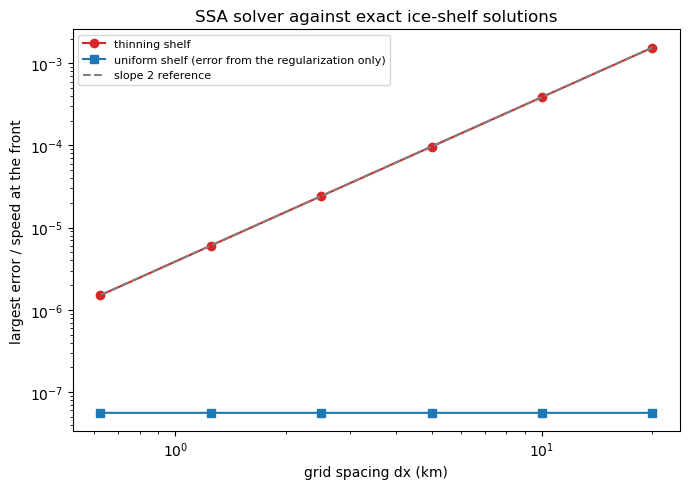

saved data/shelf_test_errors.csv


In [8]:
dx_km = np.array(DX_LIST) / 1e3
rate, log_c = np.polyfit(np.log(dx_km), np.log(errors_thinning), 1)
pairwise = np.diff(np.log(errors_thinning)) / np.diff(np.log(dx_km))
print(f"convergence rate (fit through all points): {rate:.3f}")
print(f"rate between neighbouring grid spacings: {np.round(pairwise, 3)}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(dx_km, errors_thinning, "o-", color="tab:red", label="thinning shelf")
ax.loglog(dx_km, errors_uniform, "s-", color="tab:blue", label="uniform shelf (error from the regularization only)")
ax.loglog(dx_km, errors_thinning[0] * (dx_km / dx_km[0]) ** 2, color="0.5", ls="--", label="slope 2 reference")
ax.set_xlabel("grid spacing dx (km)")
ax.set_ylabel("largest error / speed at the front")
ax.set_title("SSA solver against exact ice-shelf solutions")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_shelf_convergence.png"), dpi=150)
plt.show()

with open(os.path.join(DATA_DIR, "shelf_test_errors.csv"), "w") as f:
    f.write("dx_km,error_uniform,error_thinning,run_time_thinning_s\n")
    for dx, eu, et, rt in zip(dx_km, errors_uniform, errors_thinning, run_times):
        f.write(f"{dx},{eu:.4e},{et:.4e},{rt:.4f}\n")
print("saved data/shelf_test_errors.csv")